# GenCP demo

This notebook demonstrates how to generate synthetic GCP image chips from OSM raster maps and a topography layer (hillshades for this demonstration notebook).

A test set for the demonstration is available in the folder genCP_demo/data/dataset_topography/test . It contains OSM raster maps and hillshades raster patches over MGRS tile 31TDH.

GenCP HR topography model's weights can be downloaded [here](https://zenodo.org/records/15044428) and should be added in a "checkpoints" folder inside genCP_demo. This model has been trained on RGB images (S2 L2A TCI band) and a combination of map raster + hillshade rasters.

Generated images are saved in the data/fake_images folder. The final GenCP database (geo-referenced synthetic images) is saved in the folder "GenCP_DB".

Note: Generated images are 8 bit images.

## Installation

In [ ]:
!pip install -r requirements_HR.txt

In [3]:
import os
import random
from PIL import Image
from IPython.display import display

import matplotlib.pyplot as plt


## Visualize OSM and hillshades raster examples

Variable **dataroot_OSM** indicates path to input OSM rasters for visualization.
Variable **dataroot_topography** indicates path to input hillshades rasters for visualization.

Text(0.5, 1.0, 'Topography (hillshades)')

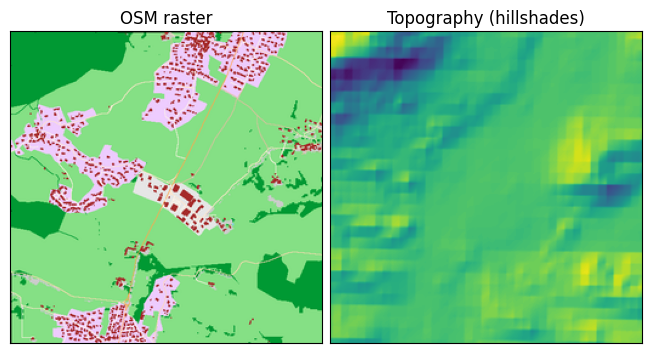

In [5]:
# path to test set
dataroot_OSM = "./data/dataset_topography/test/A"
dataroot_topography = "./data/dataset_topography/test/TOPO"

# show test data examples
img_example = random.choice(os.listdir(dataroot_OSM))
img_osm = Image.open(os.path.join(dataroot_OSM, img_example))
img_hillshades = Image.open(os.path.join(dataroot_topography, img_example))

%matplotlib inline

fig, ax = plt.subplots(1,2, constrained_layout=True)
for i in range(2):
    ax[i].xaxis.set_tick_params(labelbottom=False)
    ax[i].yaxis.set_tick_params(labelleft=False)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
ax[0].imshow(img_osm)
ax[0].set_title('OSM raster')
ax[1].imshow(img_hillshades)
ax[1].set_title('Topography (hillshades)')

## Generate images for all test samples

This section allows to generate synthetic images from OSM rasters provided as demonstration data. To generate images from your own OSM rasters / topography layers, change the dataroot path. Please refer to the [data section](https://gitlab2.telespazio.fr/isl/tim/genCP/-/blob/genCP_deliv/README.md#data) to see guidelines on how to generate OSM rasters compatible with the model's weights provided.

Add option `--gpu_ids -1` to run on CPU if GPU is not available

* `--dataroot` indicates path to training dataset
* `--name` indicates the name the experiment/model (use "genCP_HR_hillshades_model" for demonstration)
* `--checkpoints_dir` indicates the path to checkpoints folder where model's weights are saved
* `--results_dir` indicates the path to output folder for saving generated images
* `--model` is set to "test" to indicate testing mode
* `--dataset_mode` is set to "topo_single" that TOPO dataloader single mode should be used
* `--norm` is set to "batch" to indicate that batch normalization has been used during training
* `--netG` is set to "unet_256" to indicate that U-Net 256 was used as backbone for the generator during training
* `--input_nc` is set to "4" (RGB map raster are concatenated with hillshades layer)
* `--output_nc` is set to "3" (generated images are RGB images)

In [6]:
!python ../test.py  --dataroot "./data/dataset_topography/test" --name "genCP_HR_hillshades_model" --model "test" --results_dir "./data/fake_images" --checkpoints_dir "./checkpoints" --dataset_mode "topo_single" --norm "batch" --netG "unet_256" --input_nc 4 --output_nc 3

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./data/dataset_topography/test	[default: None]
             dataset_mode: topo_single                   	[default: single]
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                  gpu_ids: 0                             
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 4                             	[default: 3]
                  isTrain: False                         	[default: None]
                load_iter

## Create GenCP database

Geo-reference generated images and save files in GenCP_DB folder.

* `-t` indicates path to generated images (not geo-referenced)
* `-i` indicates path to input test data (geo-refrenced OSM rasters)
* `-o` indicates path to output folder for geo-referenced generated images

In [8]:
!python gencp_georeferencing.py -t "./data/fake_images/genCP_HR_hillshades_model/test_latest/images" -i "./data/dataset_topography/test/A" -o "./data/GenCP_DB_topography"

/home/eguasch/miniconda3/envs/genCP/lib/python3.12/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


## Visualize generated images

This section allows to visualize generated images and the corresponding 4-layer input raster (OSM + hillshades). The image displayed is choosen randomly among all generated images.

Variable **generated_dataroot** indicates path to generated images (not geo-referenced) for visualization.

Text(0.5, 1.0, 'Generated Image')

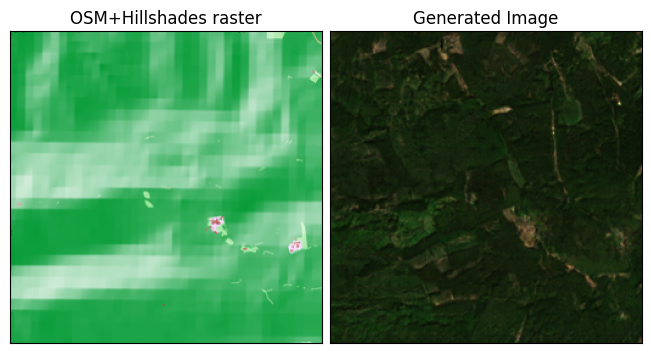

In [9]:
# path to test set
generated_dataroot = "./data/fake_images/genCP_HR_hillshades_model/test_latest/images"

# select random generated image
img_example = random.choice(os.listdir(generated_dataroot))
img_basename = img_example[:-9]
osm_raster_path = os.path.join(generated_dataroot, img_basename + "_real.png")
gen_img_path = os.path.join(generated_dataroot, img_basename + "_fake.png")

osm_img = Image.open(osm_raster_path)
gen_img = Image.open(gen_img_path)


%matplotlib inline

# display images
fig, ax = plt.subplots(1,2, constrained_layout=True)
for i in range(2):
    ax[i].xaxis.set_tick_params(labelbottom=False)
    ax[i].yaxis.set_tick_params(labelleft=False)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
ax[0].imshow(osm_img)
ax[0].set_title('OSM+Hillshades raster')
ax[1].imshow(gen_img)
ax[1].set_title('Generated Image')